# Model Development and Validation using Synthetic Data

This notebook reproduces the synthetic-data validation results for the two-stage physics-informed GPR framework presented in the manuscript.

It includes:
- synthetic deformation and stress data generation,
- Stage I learning of the undamaged hyperelastic response,
- Stage II learning of the damage response,
- comparison with baseline models, and
- validation in uniaxial and shear loading.

For exact reproduction of the manuscript results, run this notebook using the Python 3.13 environment specified in `requirements_paper.txt`, and execute all cells using **Kernel → Restart & Run All**.

In [1]:
import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import scipy.optimize
from scipy.spatial.distance import cdist
from scipy.interpolate import interp1d, CubicSpline
from scipy.integrate import simpson, trapezoid, quad
from mpl_toolkits.axes_grid1 import Divider, Size
from itertools import combinations, permutations, product
from sklearn.model_selection import KFold, train_test_split, cross_val_score
from sklearn import preprocessing
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (RBF, Matern, RationalQuadratic,
                                                  ExpSineSquared, DotProduct,
                                                  ConstantKernel, WhiteKernel)
from typing import Optional

In [2]:
# Environment check for reproducibility
import scipy
import sklearn
import pandas
import matplotlib

print("Python executable:", sys.executable)
print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("scikit-learn:", sklearn.__version__)
print("pandas:", pandas.__version__)
print("matplotlib:", matplotlib.__version__)

Python executable: C:\Users\kshit\hyperelastic-damage-gpr\test_env_paper\Scripts\python.exe
numpy: 2.3.2
scipy: 1.16.1
scikit-learn: 1.7.1
pandas: 2.3.3
matplotlib: 3.10.6


In [3]:
sys.path.append(os.path.abspath(".."))

from src.synthetic_kinematics import (
    right_cauchy_green,
    invariants,
    ref_deviatoric
)

from src.synthetic_constitutive import (
    volumetric_coefficient,
    hyperelastic_coefficients,
    response_coefficients,
    damage_coefficients,
    strain_energy_density,
    energy_spline_adaptive,
    energy_gauss_per_interval,
    nh_yeoh_damage1_S11,
    nh_yeoh_damage1_S
)

from src.constrained_gpr import (
    matern52_kernel,
    matern52_kernel_dx,
    matern52_kernel_dxdx,
    neg_log_marginal_likelihood,
    nonnegativity_constraint,
    derivative_constraint,
    penalized_obj,
    predict_mu,
    predict_var
)

## 1. Synthetic training data generation for Stage I
This section generates the uniaxial training deformation and stress data used to build the Stage I models.

In [4]:
# Deformation data generation (uniaxial tension loading) under the overall loading regime (hyperelasticity + damage)

N = 51
F_training = []
F11_train = np.linspace(1, 1.50, N)
nu = 0.49 # Poisson's ratio.

for i in range(N):
    F_training.append(np.array([F11_train[i], 0, 0, 0, (F11_train[i]**(-nu)), 0, 0, 0, (F11_train[i]**(-nu))]))
    
I1_training, I2_training, J_training = invariants(F_training)
C_training, C_bar_training = right_cauchy_green(F_training)

In [5]:
# Stress data generation artifically using the MR + Siemo-Miehe + Volokh model.

A10, A01 = 1, 0.5 # MR model parameters
kappa = 100 # Siemo-Miehe model parameter (bulk modulus)
phi, m = 0.75, 10 # Volokh model parameters (pseudo-failure energy and sharpness parameter, respectively)

S_training = [] # Full training dataset: Hyperelasticity + Damage.
S_training_vol = []
S_training_iso_h = []
W_h = []
Xi_1 = []
for i in range(len(F_training)):
    S_h_MR = 2 * (J_training[i] ** (-2/3)) * ((A10 + (I1_training[i] * A01)) * ref_deviatoric(np.eye(3), C_training[i]) - A01 * ref_deviatoric(C_bar_training[i], C_training[i]))
    S_h_SM = (kappa/2) * (J_training[i]**2 - 1) * np.linalg.inv(C_training[i])
    S_h = S_h_MR + S_h_SM
    
    W_h_MR = A10 * (I1_training[i] - 3) + A01 * (I2_training[i] - 3)
    W_h_SM = (kappa/2) * (((J_training[i]**2 - 1)/2) - np.log(J_training[i]))
    W_h.append(W_h_MR + W_h_SM)
    S_training_vol.append(np.exp(-((W_h[i]/phi)**m)) * S_h_SM)
    S_training_iso_h.append(np.exp(-((W_h[i]/phi)**m)) * S_h_MR)
    S_training.append(np.exp(-((W_h[i]/phi)**m)) * S_h)

    Xi_1.append(np.exp(-((W_h[i]/phi)**m)))

In [6]:
# Now generating input training data for the GPR#1 (vol) and GPR#2 (iso,h) models.

input_training_GPR_vol = np.vstack(np.array(J_training)) # This will be used later to train the single stage GPR model.
input_training_GPR_iso_h = np.vstack((np.array(I1_training), np.array(I2_training))).T # This will be used later to train the single stage GPR model.

# Hyperelastic regime (no damage)
N_h = int(np.ceil(N/2)) # Assuming the stress-strain data for training is hyperelastic with no damage at upto half 
# of the peak stretch.
F_h_training = []

for i in range(N_h):
    F_h_training.append(F_training[i])
    
I1_h_training, I2_h_training, J_h_training = invariants(F_h_training)
C_h_training, C_h_bar_training = right_cauchy_green(F_h_training)
input_h_training_GPR_vol = np.vstack(np.array(J_h_training))
input_h_training_GPR_iso_h = np.vstack((np.array(I1_h_training), np.array(I2_h_training))).T

# Hyperelastic stress in the undamaged material (assumed to be up to half of the peak stretch).
S_h_training = []
S_h_training_vol = []
S_h_training_iso_h = []

for i in range(N_h):
    S_h_training.append(S_training[i])
    S_h_training_vol.append(S_training_vol[i])
    S_h_training_iso_h.append(S_training_iso_h[i])

zeta1 = volumetric_coefficient(C_training, S_training_vol)
output_training_GPR_vol = np.reshape(zeta1.T,(-1,1)) # This will be used later to train the single stage GPR model.

# Output data of the GPR#1 model.
zeta1_h = volumetric_coefficient(C_h_training, S_h_training_vol)
output_h_training_GPR_vol = np.reshape(zeta1_h.T,(-1,1))

gamma1, gamma2 = hyperelastic_coefficients(C_training, S_training_iso_h)
output_training_GPR_iso_h = np.vstack((gamma1, gamma2)).T # This will be used later to train the single stage GPR model.

# Output data of the GPR#2 model.
gamma1_h, gamma2_h = hyperelastic_coefficients(C_h_training, S_h_training_iso_h)
output_h_training_GPR_iso_h = np.vstack((gamma1_h, gamma2_h)).T

In [7]:
# Fitting the 1-term volumetric NH + 2-term Yeoh + 1 term old Volokh model (defined above) to the generated
# training stress data.

S11_training, S22_training = [], []
S11_training_vol, S22_training_vol = [], []
S11_training_iso_h, S22_training_iso_h = [], []
for i in range(len(S_training)):
    S11_training.append(S_training[i][0,0])
    S22_training.append(S_training[i][1,1])
    S11_training_vol.append(S_training_vol[i][0,0])
    S22_training_vol.append(S_training_vol[i][1,1])
    S11_training_iso_h.append(S_training_iso_h[i][0,0])
    S22_training_iso_h.append(S_training_iso_h[i][1,1])

popt, pcov = scipy.optimize.curve_fit(nh_yeoh_damage1_S, F_training, np.vstack((S11_training, S22_training, S22_training)).T.flatten())

K_NH = popt[0]
C1_YH = popt[1]
C2_YH = popt[2]
phi1 = popt[3]

In [8]:
S_yh = nh_yeoh_damage1_S(F_training, popt[0], popt[1], popt[2], popt[3])

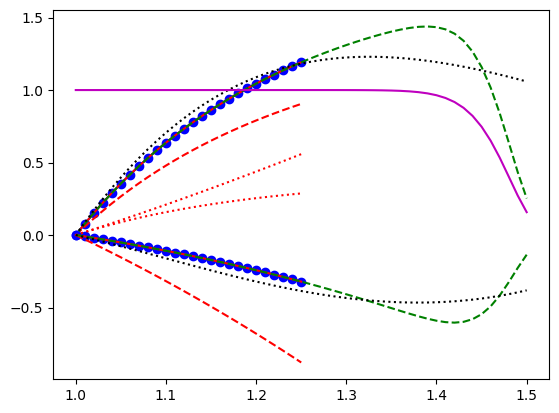

In [9]:
# Testing the accuracy of the generation of outputs (i.e., zeta1, and gamma1, gamma2) 
S11_h_training, S22_h_training = [], []
for i in range(len(S_h_training)):
    S11_h_training.append(S_h_training[i][0,0])
    S22_h_training.append(S_h_training[i][1,1])

# The recreated SM model response from the generated zeta1 training data, and the recreated MR model response
# from the generated gamma 1, gamma 2 training data. Also, the recreated total stress (SM + MR).
S_h_SM_rec = []
S_h_MR_rec = []
S_h_total_rec = []

S11_h_SM_rec, S22_h_SM_rec = [], []
S11_h_MR_rec, S22_h_MR_rec = [], []
S11_h_total_rec, S22_h_total_rec = [], []
for i in range(len(F_h_training)):
    S_h_SM_rec.append(zeta1_h[i] * np.linalg.inv(C_h_training[i]))   
    S_h_MR_rec.append(J_h_training[i] ** (-2/3) * (gamma1_h[i] * ref_deviatoric(np.eye(3), C_h_training[i]) + gamma2_h[i] * ref_deviatoric(C_h_bar_training[i], C_h_training[i])))
    S_h_total_rec.append(S_h_SM_rec[i] + S_h_MR_rec[i])
    
for i in range(len(S_h_total_rec)):
    S11_h_SM_rec.append(S_h_SM_rec[i][0,0])
    S22_h_SM_rec.append(S_h_SM_rec[i][1,1])
    S11_h_MR_rec.append(S_h_MR_rec[i][0,0])
    S22_h_MR_rec.append(S_h_MR_rec[i][1,1])
    S11_h_total_rec.append(S_h_total_rec[i][0,0])
    S22_h_total_rec.append(S_h_total_rec[i][1,1])

S11_yh, S22_yh, S33_yh = [], [], []
S_yh = nh_yeoh_damage1_S(F_training, popt[0], popt[1], popt[2], popt[3]).reshape(-1,3)
for i in range(len(F_training)):
    S11_yh.append(S_yh[i,0])
    S22_yh.append(S_yh[i,1])
    S33_yh.append(S_yh[i,2])

plt.plot(F11_train[:N_h], S11_h_training, color = 'b', marker = 'o')
plt.plot(F11_train[:N_h], S11_h_MR_rec, color = 'r', linestyle = '--')
plt.plot(F11_train[:N_h], S11_h_SM_rec, color = 'r', linestyle = ':')
plt.plot(F11_train[:N_h], S11_h_total_rec, color = 'r')
plt.plot(F11_train, S11_training, color = 'g', linestyle = '--')
plt.plot(F11_train, S11_yh, color = 'k', linestyle = ':')
plt.plot(F11_train[:N_h], S22_h_training, color = 'b', marker = 'o')
plt.plot(F11_train[:N_h], S22_h_MR_rec, color = 'r', linestyle = '--')
plt.plot(F11_train[:N_h], S22_h_SM_rec, color = 'r', linestyle = ':')
plt.plot(F11_train[:N_h], S22_h_total_rec, color = 'r')
plt.plot(F11_train, S22_training, color = 'g', linestyle = '--')
plt.plot(F11_train, S22_yh, color = 'k', linestyle = ':')

# Plotting the damage factor to make sure the chosen intact behavior limit is appropriate.
plt.plot(F11_train, Xi_1, color = 'm')
# As Xi_1[:N_h]~1, the chosen intact behavior limit is good.

In [10]:
# Numerically computing the total strain energy density function (vol + iso,h) and comparing with the analytical
# values.
W_h_numerical = strain_energy_density(C_h_training, S_h_training) # Numerically obtained strain energy density.
psi_numerical = strain_energy_density(C_training, S_training) # Modified energy density (shows asymptotic behavior)

## 2. Stage I: learning the undamaged hyperelastic response
This section trains the volumetric and isochoric GPR models using the intact (undamaged) portion of the synthetic dataset.

In [11]:
# Building the GPR#1 model using only the volumetric hyperelastic part of the data.
kernels = [ConstantKernel(1.0, (1e-4, 1e4)) * RBF(1, (1e-6, 1e6)),
           1.0 * RationalQuadratic(length_scale=1.0, alpha=0.1),
           1.0 * ExpSineSquared(length_scale=1.0, periodicity=1,
                                length_scale_bounds=(1.0e-5, 100.0),
                                periodicity_bounds=(1.0, 10.0)),
           ConstantKernel(0.1, (0.01, 10.0))
           * (DotProduct(sigma_0=1.0, sigma_0_bounds=(0.0, 10.0)) ** 2),
           1.0 * Matern(length_scale=1.0, nu=1.5),
          1.0 * Matern(length_scale=1.0, nu=2.5)]

alpha = 1.0e-2 * np.ones(input_h_training_GPR_vol.shape[0])
alpha[0] = 1.0e-5

Krig_1_vol = GaussianProcessRegressor(kernel=kernels[5], alpha=alpha, n_restarts_optimizer=20, normalize_y=True)

Krig_1_vol.fit(input_h_training_GPR_vol,output_h_training_GPR_vol)
Krig_1_vol.score(input_h_training_GPR_vol,output_h_training_GPR_vol)

0.9999897115678253

In [12]:
# Building the GPR#2 model using only the isochoric hyperelastic part of the data.

alpha = 1.0e0 * np.ones(input_h_training_GPR_iso_h.shape[0]) #KU 01192026
alpha[0] = 1e0

Krig_2_iso_h = GaussianProcessRegressor(kernel=kernels[5], alpha=alpha, n_restarts_optimizer=20, normalize_y=True)

Krig_2_iso_h.fit(input_h_training_GPR_iso_h,output_h_training_GPR_iso_h)
Krig_2_iso_h.score(input_h_training_GPR_iso_h,output_h_training_GPR_iso_h)

0.11757082767703148

## 3. Synthetic training data generation for Stage II
This section generates the uniaxial training deformation and stress data used to build the Stage II model.

In [13]:
# Generating the training data for the third GPR model, GPR#3, to capture progressive damage.

# Predicted volumetric stress over the entire loading regime (hyperelastic + damage).
# Predicted isochoric hyperelastic stress over the entire loading regime (hyperelastic + damage).

S_h_GPRpred_vol = []
S_h_GPRpred_iso_h = []
S_h_GPRpred = []
for i in range(N):
    S_h_GPRpred_vol.append(Krig_1_vol.predict(input_training_GPR_vol)[i] * np.linalg.inv(C_training[i]))
    S_h_GPRpred_iso_h.append(J_training[i] ** (-2/3) * (Krig_2_iso_h.predict(input_training_GPR_iso_h)[i,0] * ref_deviatoric(np.eye(3), C_training[i]) + Krig_2_iso_h.predict(input_training_GPR_iso_h)[i,1] * ref_deviatoric(C_bar_training[i], C_training[i])))
    S_h_GPRpred.append(S_h_GPRpred_vol[i] + S_h_GPRpred_iso_h[i])

W_h_GPRpred = strain_energy_density(C_training, S_h_GPRpred)

input_training_GPR3 = np.array(W_h_GPRpred).reshape(-1,1)

xi = damage_coefficients(S_h_GPRpred, S_training)

xi[0] = 1 # Damage coefficient at the reference state must be unity.

output_training_GPR3 = xi

In [14]:
# Comparing GPR-predicted and training stresses.
S11_h_GPRpred_vol, S22_h_GPRpred_vol = [], []
S11_h_GPRpred_iso_h, S22_h_GPRpred_iso_h = [], []
S11_h_GPRpred, S22_h_GPRpred = [], []

for i in range(N):
    S11_h_GPRpred_vol.append(S_h_GPRpred_vol[i][0,0])
    S22_h_GPRpred_vol.append(S_h_GPRpred_vol[i][1,1])
    S11_h_GPRpred_iso_h.append(S_h_GPRpred_iso_h[i][0,0])
    S22_h_GPRpred_iso_h.append(S_h_GPRpred_iso_h[i][1,1])
    S11_h_GPRpred.append(S_h_GPRpred[i][0,0])
    S22_h_GPRpred.append(S_h_GPRpred[i][1,1])

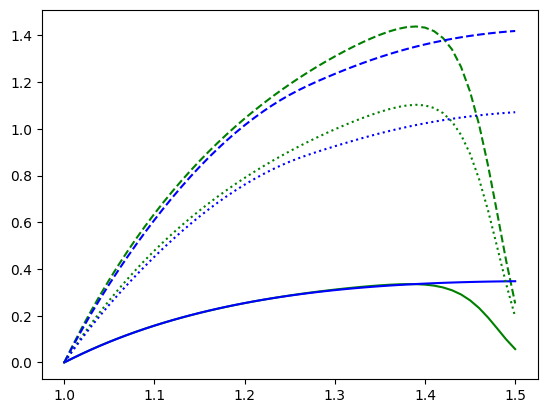

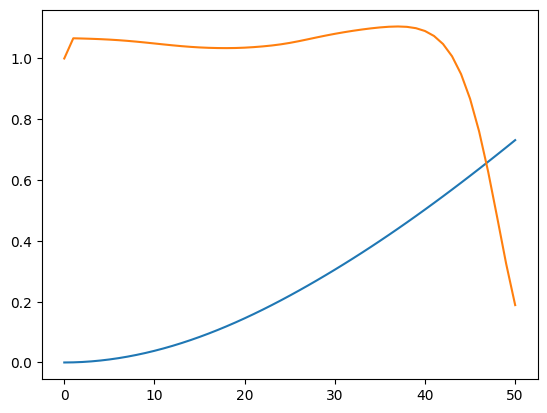

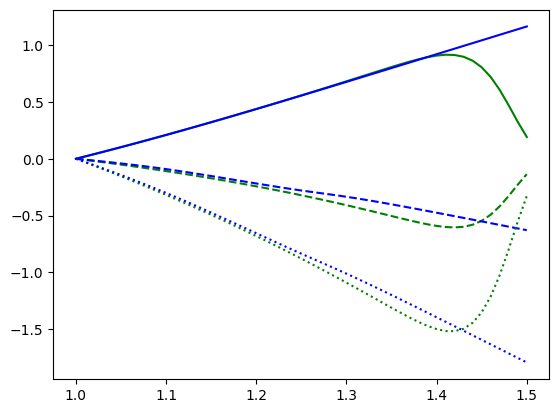

In [15]:
plt.plot(F11_train, S11_training, color = 'g', linestyle = '--')
plt.plot(F11_train, S11_h_GPRpred, color = 'b', linestyle = '--')
plt.plot(F11_train, S11_training_vol, color = 'g', linestyle = '-')
plt.plot(F11_train, S11_h_GPRpred_vol, color = 'b', linestyle = '-')
plt.plot(F11_train, S11_training_iso_h, color = 'g', linestyle = ':')
plt.plot(F11_train, S11_h_GPRpred_iso_h, color = 'b', linestyle = ':')

# plt.plot(F11_train, S22_training, color = 'g', linestyle = '-')
# plt.plot(F11_train, S22_h_GPRpred, color = 'b', linestyle = '-')
plt.show()

plt.plot(input_training_GPR3)
plt.plot(output_training_GPR3)
plt.show()

plt.plot(F11_train, S22_training, color = 'g', linestyle = '--')
plt.plot(F11_train, S22_h_GPRpred, color = 'b', linestyle = '--')
plt.plot(F11_train, S22_training_vol, color = 'g', linestyle = '-')
plt.plot(F11_train, S22_h_GPRpred_vol, color = 'b', linestyle = '-')
plt.plot(F11_train, S22_training_iso_h, color = 'g', linestyle = ':')
plt.plot(F11_train, S22_h_GPRpred_iso_h, color = 'b', linestyle = ':')

plt.show()

In [16]:
# Creating new input-output datapoints at large energy values that correspond to Xi of zero.
input_training_GPR3[-1]
linear_extrapolate = interp1d(np.arange(input_training_GPR3.shape[0]), np.squeeze(input_training_GPR3), fill_value="extrapolate")
x_extended = np.linspace(np.arange(input_training_GPR3.shape[0])[-1], np.arange(input_training_GPR3.shape[0])[-1] + (N-1),N)
input_constrained_GPR3_pos = linear_extrapolate(x_extended).reshape(-1,1)[int(0.20*(N-1)):]
output_constrained_GPR3_pos = np.zeros(input_constrained_GPR3_pos.shape)

# Combine the generated complete damage (Xi = 0) data with the original training data
input_training_GPR3_ext = np.vstack((input_training_GPR3, input_constrained_GPR3_pos))
output_training_GPR3_ext = np.vstack((output_training_GPR3, output_constrained_GPR3_pos))

## 4. Stage II: learning the damage response
This section builds standard and constrained GPR models for the stress-reduction factor as a function of strain energy density.

In [17]:
# Building two alternative GPR models for comparison: one standard GPR model between W and Xi (with extended data
# incorporating zero Xi at large W values); and one constrained GPR model that enforces monotonicity and
# non-negativity constraint on Xi in addition to the Xi = 0 data at large W values that enforces complete failure.

# Constraint data points generation.
x_cons = np.linspace(0.6,1.25, 30).reshape(-1,1)

# Testing data points generation (for evalutation of the trained model).
x_test = np.linspace(input_training_GPR3_ext[0],input_training_GPR3_ext[-1],500)

x0 = np.log([1.0, 1.0])  # Initial value of Kernel hyperparameters. Note: We use log parameters to feed into x0,
# which are then shifted back to the original parameters in NLML and constraint functions. In this way, it is not
# the actual parameters but the log of parameters that are resulted by the optimizer. This ensures parameters
# always stay positive during the optimization process, important for numerical stability.
noise = 1e-4

# === Standard GPR Optimization ===
res_std = scipy.optimize.minimize(
    neg_log_marginal_likelihood,
    x0,
    args=(input_training_GPR3_ext, output_training_GPR3_ext, noise),
    method='L-BFGS-B',
    options={'disp': True, 'maxiter': 1000}
)
lengthscale_std, variance_std = np.exp(res_std.x)
mu_std = predict_mu(input_training_GPR3_ext, output_training_GPR3_ext, x_test, lengthscale_std, variance_std, noise)

# === Constrained GPR Optimization using a Penalized positivity NLML (for tighter, less-smooth fits) ===
cons = [
    {'type': 'ineq', 'fun': lambda p: nonnegativity_constraint(p, input_training_GPR3_ext, output_training_GPR3_ext, x_cons, noise)},
    {'type': 'ineq', 'fun': lambda p: derivative_constraint(p, input_training_GPR3_ext, output_training_GPR3_ext, x_cons, noise)}
]

# Define how strictly constraints are enforced via the penalty term (lam).
lam = 1e3         # penalty strength

res_pen = scipy.optimize.minimize(
    lambda p: penalized_obj(p, input_training_GPR3_ext, output_training_GPR3_ext, x_cons, lam, noise),
    res_std.x,
    method='L-BFGS-B',
    options={'maxiter': 2000}
)
lengthscale_pen, variance_pen = np.exp(res_pen.x)
mu_pen = predict_mu(input_training_GPR3_ext, output_training_GPR3_ext, x_test, lengthscale_pen, variance_pen, noise)

# === An alternative method: Constrained hyperparameter optimization with SLSQP or COBYLA. ===
res_cons2 = scipy.optimize.minimize(
    neg_log_marginal_likelihood,
    x0,
    args=(input_training_GPR3_ext, output_training_GPR3_ext, noise),
    constraints=cons,
    method='COBYLA',
    options={'disp': False, 'maxiter': 1000} # Turn "disp" to True to see detailed convergence messages and results.
)

lengthscale_cons2, variance_cons2 = np.exp(res_cons2.x)
mu_cons2 = predict_mu(input_training_GPR3_ext, output_training_GPR3_ext, x_test, lengthscale_cons2, variance_cons2, noise)


C:\Users\kshit\AppData\Local\Temp\ipykernel_53776\1019306600.py:18: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res_std = scipy.optimize.minimize(


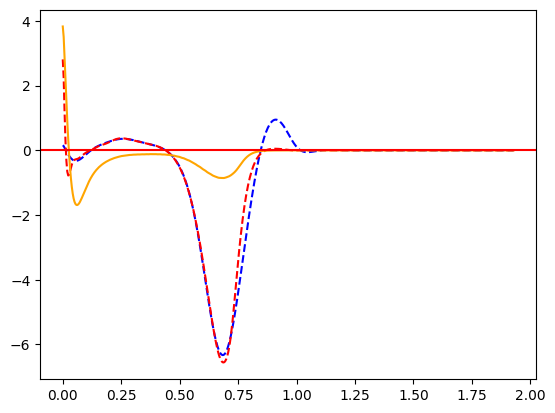

In [18]:
# Computing the derivatives of the posteriors to check monotonicity in the three GPRs.
derivative_std = np.gradient(mu_std.flatten(),x_test.flatten())
derivative_pen = np.gradient(mu_pen.flatten(),x_test.flatten())
derivative_cons2 = np.gradient(mu_cons2.flatten(),x_test.flatten())

plt.plot(x_test, derivative_std, 'b--')
plt.plot(x_test, derivative_pen, 'r--')
plt.plot(x_test, derivative_cons2, 'orange')
plt.axhline(y=0, color='r', linestyle='-')

In [19]:
# Building classical undamaged GPR models (vol and iso_h) that consider the full stress strain data without
# dividing it into intact and damage components.

# The input-output datasets were generated previously: input_training_GPR_vol, input_training_GPR_iso_h,
# output_h_training_GPR_vol, and output_h_training_GPR_iso_h

# Creating new input-output datapoints at large input values that correspond to output of zero.
linear_extrapolate_vol = interp1d(np.arange(input_training_GPR_vol.shape[0]), np.squeeze(input_training_GPR_vol[:,0]), fill_value="extrapolate")
x_extended_vol = np.linspace(np.arange(input_training_GPR_vol.shape[0])[-1], np.arange(input_training_GPR_vol.shape[0])[-1] + (N-1),N)

linear_extrapolate_iso_h_1 = interp1d(np.arange(input_training_GPR_iso_h.shape[0]), np.squeeze(input_training_GPR_iso_h[:,0]), fill_value="extrapolate")
x_extended_iso_h_1 = np.linspace(np.arange(input_training_GPR_iso_h.shape[0])[-1], np.arange(input_training_GPR_iso_h.shape[0])[-1] + (N-1),N)

linear_extrapolate_iso_h_2 = interp1d(np.arange(input_training_GPR_iso_h.shape[0]), np.squeeze(input_training_GPR_iso_h[:,1]), fill_value="extrapolate")
x_extended_iso_h_2 = np.linspace(np.arange(input_training_GPR_iso_h.shape[0])[-1], np.arange(input_training_GPR_iso_h.shape[0])[-1] + (N-1),N)

input_ext_vol = linear_extrapolate_vol(x_extended_vol).reshape(-1,1)[int(0.20*(N-1)):]
input_ext_iso_h_1 = linear_extrapolate_iso_h_1(x_extended_iso_h_1).reshape(-1,1)[int(0.20*(N-1)):]
input_ext_iso_h_2 = linear_extrapolate_iso_h_2(x_extended_iso_h_2).reshape(-1,1)[int(0.20*(N-1)):]

# Combine the generated complete damage (output = 0) data with the original training data
input_training_GPR_vol_direct = np.vstack((input_training_GPR_vol, input_ext_vol))
output_training_GPR_vol_direct = np.vstack((output_training_GPR_vol, np.zeros(input_ext_vol.shape)))

input_training_GPR_iso_h_direct = np.vstack((input_training_GPR_iso_h, np.hstack((input_ext_iso_h_1, input_ext_iso_h_2))))
output_training_GPR_iso_h_direct = np.vstack((output_training_GPR_iso_h, np.zeros(np.hstack((input_ext_iso_h_1, input_ext_iso_h_2)).shape)))

In [20]:
# Building GPR models between invariants and scaled response functions directly, bypassing the 2-stage framework.
alpha = 1.0e-2 * np.ones(input_training_GPR_vol_direct.shape[0])
alpha[0] = 1.0e-5
Krig_vol_direct = GaussianProcessRegressor(kernel=kernels[5], alpha=alpha, n_restarts_optimizer=20, normalize_y=True)
Krig_vol_direct.fit(input_training_GPR_vol_direct,output_training_GPR_vol_direct)
print(Krig_vol_direct.score(input_training_GPR_vol_direct,output_training_GPR_vol_direct))

alpha = 1.0e-0 * np.ones(input_training_GPR_iso_h_direct.shape[0]) #KU 01192026
alpha[0] = 1e-0
Krig_iso_h_direct = GaussianProcessRegressor(kernel=kernels[5], alpha=alpha, n_restarts_optimizer=20, normalize_y=True)
Krig_iso_h_direct.fit(input_training_GPR_iso_h_direct,output_training_GPR_iso_h_direct)
print(Krig_iso_h_direct.score(input_training_GPR_iso_h_direct,output_training_GPR_iso_h_direct))

0.9994429592811559
0.4022550736141383


In [21]:
# Building a classical 6-6 GPR mapping between C and S (symmetric components)
# Now, comparing the above results with a 6-6 mapping. Here, the 6 inputs are
# the unique components of the symmetric C tensor, and the 6 outputs are the unique components of the
# symmetric 2nd P-K stress.

C11_training = [C_training[i][0,0] for i in range(len(C_training))] 
C12_training = [C_training[i][0,1] for i in range(len(C_training))]
C13_training = [C_training[i][0,2] for i in range(len(C_training))]
C22_training = [C_training[i][1,1] for i in range(len(C_training))]
C23_training = [C_training[i][1,2] for i in range(len(C_training))]
C33_training = [C_training[i][2,2] for i in range(len(C_training))]

input_train_6_6 = np.vstack((np.array(C11_training), np.array(C12_training), np.array(C13_training), np.array(C22_training),
                         np.array(C23_training), np.array(C33_training))).T

S11_training = [S_training[i][0,0] for i in range(len(S_training))] 
S12_training = [S_training[i][0,1] for i in range(len(S_training))]
S13_training = [S_training[i][0,2] for i in range(len(S_training))]
S22_training = [S_training[i][1,1] for i in range(len(S_training))]
S23_training = [S_training[i][1,2] for i in range(len(S_training))]
S33_training = [S_training[i][2,2] for i in range(len(S_training))]

output_train_6_6 = np.vstack((np.array(S11_training), np.array(S12_training), np.array(S13_training), np.array(S22_training),
                         np.array(S23_training), np.array(S33_training))).T

Krig_6_6 = GaussianProcessRegressor(kernel=kernels[5], alpha=1.0e-2, n_restarts_optimizer=10, normalize_y=True)
Krig_6_6.fit(input_train_6_6,output_train_6_6)
Krig_6_6.score(input_train_6_6,output_train_6_6)

0.9997371827660674

## 5. Validation in uniaxial loading
This section evaluates the trained models under tensile and compressive uniaxial loading and compares predictions against the ground-truth constitutive model.

In [22]:
# Testing the accuracy of the trained GPR model.

F_test = []
N = 81
F11 = np.linspace(0.5, 1.5, N)
for i in range(N):
    F_test.append(np.array([F11[i], 0, 0, 0, (F11[i]**(-nu)), 0, 0, 0, (F11[i]**(-nu))]))
    
I1_test, I2_test, J_test = invariants(F_test)
C_test, C_bar_test = right_cauchy_green(F_test)
input_test_vol = np.vstack(np.array(J_test))
input_test_iso_h = np.vstack((np.array(I1_test), np.array(I2_test))).T

# GPR#1 model
output_h_test_vol = Krig_1_vol.predict(input_test_vol)

# GPR#2 model
output_h_test_iso_h = Krig_2_iso_h.predict(input_test_iso_h)

S_h_test = []
for i in range(len(F_test)):
    S_h_test_vol = output_h_test_vol[i] * np.linalg.inv(C_test[i])
    S_h_test_iso_h = J_test[i] ** (-2/3) * (output_h_test_iso_h[i,0] * ref_deviatoric(np.eye(3), C_test[i]) + output_h_test_iso_h[i,1] * ref_deviatoric(C_bar_test[i], C_test[i]))
    S_h_test.append(S_h_test_vol + S_h_test_iso_h)

S11_h_test, S22_h_test = [], []
for i in range(len(F_test)):
    S11_h_test.append(S_h_test[i][0,0])
    S22_h_test.append(S_h_test[i][1,1])
    
# Compute the strain energy density. This needs to be done separately for tension and compression.
W_h_ten_temp = strain_energy_density(C_test[int(N/2):], S_h_test[int(N/2):])
W_h_comp_temp = strain_energy_density(list(reversed(C_test[:int(N/2)+1])), list(reversed(S_h_test[:int(N/2)+1])))
W_h_test = list(reversed(W_h_comp_temp)) + W_h_ten_temp[1:]

In [23]:
# GPR#3 model with monotonicity and non-negativity constraints.
input_test_GPR3 = np.array(W_h_test).reshape(-1,1)

output_test = predict_mu(input_training_GPR3_ext, output_training_GPR3_ext, input_test_GPR3, lengthscale_pen, variance_pen, noise)

S_test = []
for i in range(len(F_test)):
    S_test.append(output_test[i] * S_h_test[i])
    
S11_test, S22_test = [], []
for i in range(len(F_test)):
    S11_test.append(S_test[i][0,0])
    S22_test.append(S_test[i][1,1])
    
# GPR#3 model with no constraint (standard GPR).
output_test_stdGPR = predict_mu(input_training_GPR3_ext, output_training_GPR3_ext, input_test_GPR3, lengthscale_std, variance_std, noise)

S_test_stdGPR = []
for i in range(len(F_test)):
    S_test_stdGPR.append(output_test_stdGPR[i] * S_h_test[i])
    
S11_test_stdGPR, S22_test_stdGPR = [], []
for i in range(len(F_test)):
    S11_test_stdGPR.append(S_test_stdGPR[i][0,0])
    S22_test_stdGPR.append(S_test_stdGPR[i][1,1])

In [24]:
# Compute total strain energy density from the fully trained model. This needs to be done separately for tension and compression.
W_ten_test = strain_energy_density(C_test[int(N/2):], S_test[int(N/2):])
W_comp_test = strain_energy_density(list(reversed(C_test[:int(N/2)+1])), list(reversed(S_test[:int(N/2)+1])))
W_test = list(reversed(W_comp_test)) + W_ten_test[1:]

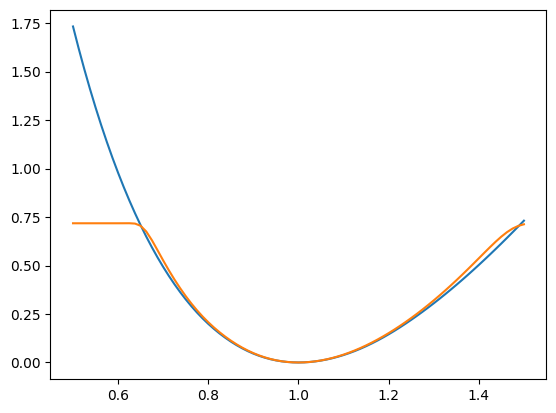

In [25]:
# Compare intact vs total strain energy density.
plt.plot(F11, W_h_test)
plt.plot(F11, W_test)
plt.show()

In [26]:
# Classical direct GPR.

output_test_GPR_vol_direct = Krig_vol_direct.predict(input_test_vol)
output_test_GPR_iso_h_direct = Krig_iso_h_direct.predict(input_test_iso_h)

S_test_GPR_direct = []
for i in range(len(F_test)):
    S_test_GPR_vol_direct = output_test_GPR_vol_direct[i] * np.linalg.inv(C_test[i])
    S_test_GPR_iso_h_direct = J_test[i] ** (-2/3) * (output_test_GPR_iso_h_direct[i,0] * ref_deviatoric(np.eye(3), C_test[i]) + output_test_GPR_iso_h_direct[i,1] * ref_deviatoric(C_bar_test[i], C_test[i]))
    S_test_GPR_direct.append(S_test_GPR_vol_direct + S_test_GPR_iso_h_direct)

S11_test_GPR_direct, S22_test_GPR_direct = [], []
for i in range(len(F_test)):
    S11_test_GPR_direct.append(S_test_GPR_direct[i][0,0])
    S22_test_GPR_direct.append(S_test_GPR_direct[i][1,1])

In [27]:
# Classical 6-6 mapping model
C11_test = [C_test[i][0,0] for i in range(len(C_test))] 
C12_test = [C_test[i][0,1] for i in range(len(C_test))]
C13_test = [C_test[i][0,2] for i in range(len(C_test))]
C22_test = [C_test[i][1,1] for i in range(len(C_test))]
C23_test = [C_test[i][1,2] for i in range(len(C_test))]
C33_test = [C_test[i][2,2] for i in range(len(C_test))]

input_test_6_6 = np.vstack((np.array(C11_test), np.array(C12_test), np.array(C13_test), np.array(C22_test),
                         np.array(C23_test), np.array(C33_test))).T
output_test_6_6 = Krig_6_6.predict(input_test_6_6)

S_test_6_6 = []
for i in range(len(F_test)):
    S_test_6_6.append(np.array([[output_test_6_6[i][0], output_test_6_6[i][1], output_test_6_6[i][2]],
                           [output_test_6_6[i][1], output_test_6_6[i][3], output_test_6_6[i][4]],
                           [output_test_6_6[i][2], output_test_6_6[i][4], output_test_6_6[i][5]]]))

S11_test_6_6, S22_test_6_6 = [], []
for i in range(len(F_test)):
    S11_test_6_6.append(S_test_6_6[i][0,0])
    S22_test_6_6.append(S_test_6_6[i][1,1])

In [28]:
# Extended SM+MR+Damage Model (ground truth)

S_ground_truth = []
W_h_ground_truth = []
for i in range(len(F_test)):
    S_h_MR_temp = 2 * (input_test_vol[i] ** (-2/3)) * ((A10 + (input_test_iso_h[i,0] * A01)) * ref_deviatoric(np.eye(3), C_test[i]) - A01 * ref_deviatoric(C_bar_test[i], C_test[i]))
    S_h_SM_temp = (kappa/2) * (input_test_vol[i]**2 - 1) * np.linalg.inv(C_test[i])
    S_h_temp = S_h_MR_temp + S_h_SM_temp
    
    W_h_MR_temp = A10 * (input_test_iso_h[i,0] - 3) + A01 * (input_test_iso_h[i,1] - 3)
    W_h_SM_temp = (kappa/2) * (((input_test_vol[i]**2 - 1)/2) - np.log(input_test_vol[i]))
    W_h_ground_truth.append(W_h_MR_temp + W_h_SM_temp)
    S_ground_truth.append(np.exp(-((W_h_ground_truth[i]/phi)**m)) * S_h_temp)

S11_ground_truth, S22_ground_truth = [], []
for i in range(len(F_test)):
    S11_ground_truth.append(S_ground_truth[i][0,0])
    S22_ground_truth.append(S_ground_truth[i][1,1])
    
# Predictions of the 1-term volumetric NH + 2-term Yeoh + 1 term old Volokh model.
S_YH = []
W_YH = []
for i in range(len(F_test)):
    W_YH.append(((K_NH/2) * (input_test_vol[i] - 1)**2) + (C1_YH * (input_test_iso_h[i,0] - 3)) + (C2_YH * ((input_test_iso_h[i,0] - 3)**2)))
    S_YH.append(np.exp(-W_YH[i]/phi1) * ((K_NH*input_test_vol[i]*(input_test_vol[i] - 1)* np.linalg.inv(C_test[i])) +
        ((input_test_vol[i]**(-2/3)) * (2*C1_YH + 4*C2_YH*(input_test_iso_h[i,0] - 3))
               * ref_deviatoric(np.eye(3), C_test[i]))))

S11_YH, S22_YH = [], []
for i in range(len(F_test)):
    S11_YH.append(S_YH[i][0,0])
    S22_YH.append(S_YH[i][1,1])

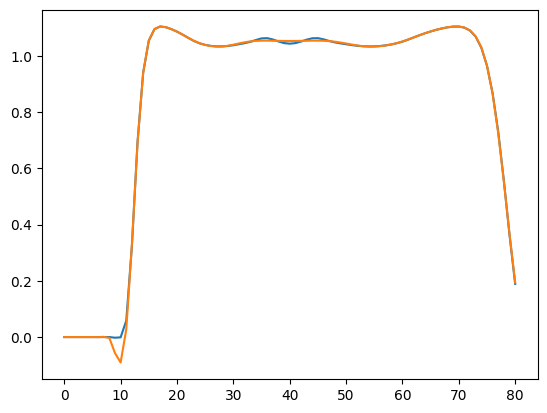

In [29]:
# Quick diagnostics.
plt.plot(output_test)
plt.plot(output_test_stdGPR)

## 6. Validation in shear loading
This section evaluates the trained models under shear deformation and compares predictions against the ground-truth constitutive model.

In [30]:
# Testing the accuracy of the trained GPR model in the shear deformation mode.

F_test_sh = []
M = 51
F12 = np.linspace(0, 0.8, M)
for i in range(M):
    F_test_sh.append(np.array([1, F12[i], 0, 0, 1, 0, 0, 0, 1]))
    
I1_test_sh, I2_test_sh, J_test_sh = invariants(F_test_sh)
C_test_sh, C_bar_test_sh = right_cauchy_green(F_test_sh)
input_test_sh_vol = np.vstack(np.array(J_test_sh))
input_test_sh_iso_h = np.vstack((np.array(I1_test_sh), np.array(I2_test_sh))).T

# GPR#1 model
output_h_test_sh_vol = Krig_1_vol.predict(input_test_sh_vol)

# GPR#2 model
output_h_test_sh_iso_h = Krig_2_iso_h.predict(input_test_sh_iso_h)

S_h_test_sh = []
for i in range(len(F_test_sh)):
    S_h_test_sh_vol = output_h_test_sh_vol[i] * np.linalg.inv(C_test_sh[i])
    S_h_test_sh_iso_h = J_test_sh[i] ** (-2/3) * (output_h_test_sh_iso_h[i,0] * ref_deviatoric(np.eye(3), C_test_sh[i]) + output_h_test_sh_iso_h[i,1] * ref_deviatoric(C_bar_test_sh[i], C_test_sh[i]))
    S_h_test_sh.append(S_h_test_sh_vol + S_h_test_sh_iso_h)

S12_h_test_sh = []
for i in range(len(F_test_sh)):
    S12_h_test_sh.append(S_h_test_sh[i][0,1])
    
# Compute the strain energy density. This needs to be done separately for tension and compression.
W_h_test_sh = strain_energy_density(C_test_sh, S_h_test_sh)

In [31]:
# GPR#3 model with monotonicity and non-negativity constraints.
input_test_GPR3_sh = np.array(W_h_test_sh).reshape(-1,1)

output_test_sh = predict_mu(input_training_GPR3_ext, output_training_GPR3_ext, input_test_GPR3_sh, lengthscale_pen, variance_pen, noise)

S_test_sh = []
for i in range(len(F_test_sh)):
    S_test_sh.append(output_test_sh[i] * S_h_test_sh[i])
    
S12_test_sh = []
for i in range(len(F_test_sh)):
    S12_test_sh.append(S_test_sh[i][0,1])
    
# GPR#3 model with no constraint (standard GPR).
output_test_stdGPR_sh = predict_mu(input_training_GPR3_ext, output_training_GPR3_ext, input_test_GPR3_sh, lengthscale_std, variance_std, noise)

S_test_stdGPR_sh = []
for i in range(len(F_test_sh)):
    S_test_stdGPR_sh.append(output_test_stdGPR_sh[i] * S_h_test_sh[i])
    
S12_test_stdGPR_sh = []
for i in range(len(F_test_sh)):
    S12_test_stdGPR_sh.append(S_test_stdGPR_sh[i][0,1])

In [32]:
# Classical 6-6 mapping model
C11_test_sh = [C_test_sh[i][0,0] for i in range(len(C_test_sh))] 
C12_test_sh = [C_test_sh[i][0,1] for i in range(len(C_test_sh))]
C13_test_sh = [C_test_sh[i][0,2] for i in range(len(C_test_sh))]
C22_test_sh = [C_test_sh[i][1,1] for i in range(len(C_test_sh))]
C23_test_sh = [C_test_sh[i][1,2] for i in range(len(C_test_sh))]
C33_test_sh = [C_test_sh[i][2,2] for i in range(len(C_test_sh))]

input_test_6_6_sh = np.vstack((np.array(C11_test_sh), np.array(C12_test_sh), np.array(C13_test_sh), np.array(C22_test_sh),
                         np.array(C23_test_sh), np.array(C33_test_sh))).T
output_test_6_6_sh = Krig_6_6.predict(input_test_6_6_sh)

S_test_6_6_sh = []
for i in range(len(F_test_sh)):
    S_test_6_6_sh.append(np.array([[output_test_6_6_sh[i][0], output_test_6_6_sh[i][1], output_test_6_6_sh[i][2]],
                           [output_test_6_6_sh[i][1], output_test_6_6_sh[i][3], output_test_6_6_sh[i][4]],
                           [output_test_6_6_sh[i][2], output_test_6_6_sh[i][4], output_test_6_6_sh[i][5]]]))

S12_test_6_6_sh = []
for i in range(len(F_test_sh)):
    S12_test_6_6_sh.append(S_test_6_6_sh[i][0,1])
    

In [33]:
# Single-stage GPR model (direct mapping)

output_test_GPR_vol_direct_sh = Krig_vol_direct.predict(input_test_sh_vol)
output_test_GPR_iso_h_direct_sh = Krig_iso_h_direct.predict(input_test_sh_iso_h)

S_test_GPR_direct_sh = []
for i in range(len(F_test_sh)):
    S_test_GPR_vol_direct_sh = output_test_GPR_vol_direct_sh[i] * np.linalg.inv(C_test_sh[i])
    S_test_GPR_iso_h_direct_sh = J_test_sh[i] ** (-2/3) * (output_test_GPR_iso_h_direct_sh[i,0] * ref_deviatoric(np.eye(3), C_test_sh[i]) + output_test_GPR_iso_h_direct_sh[i,1] * ref_deviatoric(C_bar_test_sh[i], C_test_sh[i]))
    S_test_GPR_direct_sh.append(S_test_GPR_vol_direct_sh + S_test_GPR_iso_h_direct_sh)

S12_test_GPR_direct_sh = []
for i in range(len(F_test_sh)):
    S12_test_GPR_direct_sh.append(S_test_GPR_direct_sh[i][0,1])

In [34]:
# Extended SM+MR+Damage Model (ground truth)

S_ground_truth_sh = []
W_h_ground_truth_sh = []
for i in range(len(F_test_sh)):
    S_h_MR_temp_sh = 2 * (input_test_sh_vol[i] ** (-2/3)) * ((A10 + (input_test_sh_iso_h[i,0] * A01)) * ref_deviatoric(np.eye(3), C_test_sh[i]) - A01 * ref_deviatoric(C_bar_test_sh[i], C_test_sh[i]))
    S_h_SM_temp_sh = (kappa/2) * (input_test_sh_vol[i]**2 - 1) * np.linalg.inv(C_test_sh[i])
    S_h_temp_sh = S_h_MR_temp_sh + S_h_SM_temp_sh
    
    W_h_MR_temp_sh = A10 * (input_test_sh_iso_h[i,0] - 3) + A01 * (input_test_sh_iso_h[i,1] - 3)
    W_h_SM_temp_sh = (kappa/2) * (((input_test_sh_vol[i]**2 - 1)/2) - np.log(input_test_sh_vol[i]))
    W_h_ground_truth_sh.append(W_h_MR_temp_sh + W_h_SM_temp_sh)
    S_ground_truth_sh.append(np.exp(-((W_h_ground_truth_sh[i]/phi)**m)) * S_h_temp_sh)

S12_ground_truth_sh = []
for i in range(len(F_test_sh)):
    S12_ground_truth_sh.append(S_ground_truth_sh[i][0,1])

# Predictions of the 1-term volumetric NH + 2-term Yeoh + 1 term old Volokh model.
S_YH_sh = []
W_YH_sh = []
for i in range(len(F_test_sh)):
    W_YH_sh.append(((K_NH/2) * (input_test_sh_vol[i] - 1)**2) + (C1_YH * (input_test_sh_iso_h[i,0] - 3)) + (C2_YH * ((input_test_sh_iso_h[i,0] - 3)**2)))
    S_YH_sh.append(np.exp(-W_YH_sh[i]/phi1) * ((K_NH*input_test_sh_vol[i]*(input_test_sh_vol[i] - 1)* np.linalg.inv(C_test_sh[i])) +
        ((input_test_sh_vol[i]**(-2/3)) * (2*C1_YH + 4*C2_YH*(input_test_sh_iso_h[i,0] - 3))
               * ref_deviatoric(np.eye(3), C_test_sh[i]))))

S12_YH_sh = []
for i in range(len(F_test_sh)):
    S12_YH_sh.append(S_YH_sh[i][0,1])

In [35]:
# Combining the uniaxial and shear testing data.

S_test_overall = S_test + S_test_sh
S_test_stdGPR_overall = S_test_stdGPR + S_test_stdGPR_sh
S_test_6_6_overall = S_test_6_6 + S_test_6_6_sh
S_ground_truth_overall = S_ground_truth + S_ground_truth_sh
S_YH_overall = S_YH + S_YH_sh
S_test_GPR_direct_overall = S_test_GPR_direct + S_test_GPR_direct_sh

## 7. Error analysis and manuscript figures
This section computes error metrics and generates the figures used in the manuscript.

In [36]:
# Testing the accuracy of the trained GPR model by computing error metrics and comparing with errors from YH model and 6-6 mapping GPR model.
# Computing error metric for the GPR surrogate model.
norm_ground_truth = []
for i in range(len(S_test_overall)):
    norm_ground_truth.append(np.linalg.norm(S_ground_truth_overall[i]))
max_norm_ground_truth = np.max(norm_ground_truth)

err_test_overall = []
for i in range(len(S_test_overall)):
    S_diff = S_test_overall[i] - S_ground_truth_overall[i]
    # Avoiding division by very small values by adding a max condition in the denominator.
    err_test_overall.append(np.linalg.norm(S_diff) / np.max((0.01*max_norm_ground_truth, norm_ground_truth[i])))

err_test_overall_ = err_test_overall.copy()

mean_err_trainregime = np.nanmean(np.array(err_test_overall_)[40:81]) # mean error in the training regime of F11 = 1 to 1.5.
max_err_trainregime = np.nanmax(np.array(err_test_overall_)[40:81])
mean_err_test = np.nanmean(np.array(err_test_overall_))# Overall mean error

# Computing error metric for the YH model.
err_YH_overall = []
for i in range(len(S_test_overall)):
    S_diff = S_YH_overall[i] - S_ground_truth_overall[i]
    err_YH_overall.append(np.linalg.norm(S_diff) / np.max((0.01*max_norm_ground_truth, norm_ground_truth[i])))

err_YH_overall_ = err_YH_overall.copy()

mean_err_trainregime_YH = np.nanmean(np.array(err_YH_overall_)[40:81]) # mean error in the training regime of F11 = 1 to 1.5.
max_err_trainregime_YH = np.nanmax(np.array(err_YH_overall_)[40:81])
mean_err_YH = np.nanmean(np.array(err_YH_overall_))# Overall mean error

# Computing error metric for the 6-6 classical mapping model.
err_test_6_6_overall = []
for i in range(len(S_test_6_6_overall)):
    S_diff = S_test_6_6_overall[i] - S_ground_truth_overall[i]
    err_test_6_6_overall.append(np.linalg.norm(S_diff) / np.max((0.01*max_norm_ground_truth, norm_ground_truth[i])))

err_test_6_6_overall_ = err_test_6_6_overall.copy()

mean_err_trainregime_6_6 = np.nanmean(np.array(err_test_6_6_overall_)[40:81]) # mean error in the training regime of J = 0.75 to 1.
max_err_trainregime_6_6 = np.nanmax(np.array(err_test_6_6_overall_)[40:81])
mean_err_test_6_6 = np.nanmean(np.array(err_test_6_6_overall_))# Overall mean error

# Computing error metric for the single-stage GPR model (direct mapping).
err_test_GPR_direct_overall = []
for i in range(len(S_test_GPR_direct_overall)):
    S_diff = S_test_GPR_direct_overall[i] - S_ground_truth_overall[i]
    err_test_GPR_direct_overall.append(np.linalg.norm(S_diff) / np.max((0.01*max_norm_ground_truth, norm_ground_truth[i])))


err_test_GPR_direct_overall_ = err_test_GPR_direct_overall.copy()

mean_err_trainregime_GPR_direct = np.nanmean(np.array(err_test_GPR_direct_overall_)[40:81]) # mean error in the training regime of J = 0.75 to 1.
max_err_trainregime_GPR_direct = np.nanmax(np.array(err_test_GPR_direct_overall_)[40:81])
mean_err_test_GPR_direct = np.nanmean(np.array(err_test_GPR_direct_overall_))# Overall mean error

print('Mean relative errors in the training regime:', mean_err_trainregime, mean_err_trainregime_YH, mean_err_trainregime_6_6,mean_err_trainregime_GPR_direct)
print('Max relative errors in the training regime:', max_err_trainregime, max_err_trainregime_YH, max_err_trainregime_6_6, max_err_trainregime_GPR_direct)
print('Mean relative errors in the testing regime:', mean_err_test, mean_err_YH, mean_err_test_6_6, mean_err_test_GPR_direct)

Mean relative errors in the training regime: 0.04518683749559091 0.21653190459076446 0.01616083722350488 0.182012054768964
Max relative errors in the training regime: 0.08920991356294136 2.767058730870293 0.32444309597368753 2.830392899965053
Mean relative errors in the testing regime: 0.16598054507389187 10.814176817393783 1.97481885065443 5.238831273159522


<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
C:\Users\kshit\AppData\Local\Temp\ipykernel_53776\716379407.py:34: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda$')


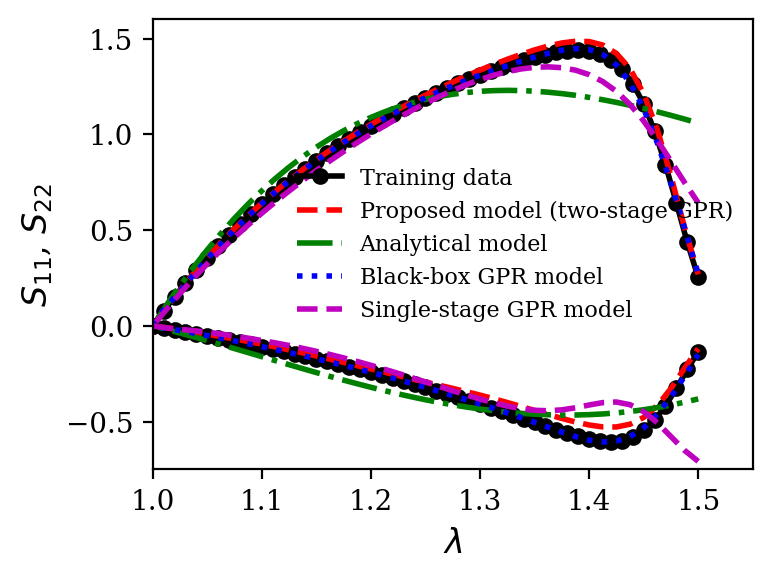

In [37]:
# Plotting the fitted stress by the data-driven model.
# Plot 3a. Training data and Fitted Response.
plt.rc('font', family='serif')
plt.rcParams["figure.autolayout"] = True
plt.rc('xtick', labelsize='medium')
plt.rc('ytick', labelsize='medium')
plt.rc('axes', labelsize='large')

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

ax.plot(F11_train, S11_training, c = 'k', marker = 'o', markersize = '5', linewidth = 2, label = 'Training data') #marker = 'o', markersize = '5',
ax.plot(F11[40:], np.array(S11_test)[40:], c = 'r', linestyle = '--', linewidth = 2, label = 'Proposed model (two-stage GPR)')
ax.plot(F11_train, S22_training, marker = 'o', markersize = '5', c = 'k', linewidth = 2) #marker = 'o', markersize = '5', 
ax.plot(F11[40:], np.array(S22_test)[40:], c = 'r', linestyle = '--', linewidth = 2)

ax.plot(F11, S11_YH, c = 'g', linestyle = '-.', linewidth = 2, label = 'Analytical model')
ax.plot(F11, S11_test_6_6, c = 'b', linestyle = ':', linewidth = 2, label = 'Black-box GPR model')
ax.plot(F11, S11_test_GPR_direct, c = 'm', linestyle = '--', linewidth = 2, label = 'Single-stage GPR model')
ax.plot(F11, S22_YH, c = 'g', linestyle = '-.', linewidth = 2)
ax.plot(F11, S22_test_6_6, c = 'b', linestyle = ':', linewidth = 2)
ax.plot(F11, S22_test_GPR_direct, c = 'm', linestyle = '--', linewidth = 2)

plt.ylim((-0.75, 1.6))
plt.xlim((1, 1.55))

ax.set_xlabel('$\lambda$')
ax.set_ylabel('$S_{11}$, $S_{22}$')
ax.legend(frameon=False, prop={'size': 8})
plt.savefig("../results/Hyperelastic_training_fitting.svg")
plt.show()

<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
C:\Users\kshit\AppData\Local\Temp\ipykernel_53776\2656979299.py:22: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda$')


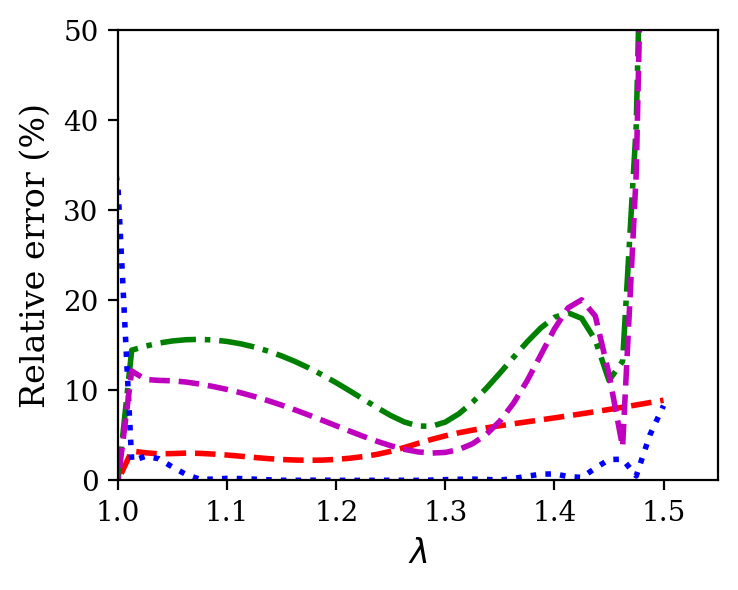

In [38]:
# Plot 3b: Relative error metric versus (lambda stretch) in the fitting regime

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

#ax = fig.add_subplot(1, 1, 1)
plt.xlim([1, 1.55])
plt.ylim([0, 50])

ax.plot(F11, 100 * np.array(err_test_overall[:81]), c = 'r', linestyle = '--', linewidth = 2, label = 'Surrogate model')
ax.plot(F11, 100 * np.array(err_YH_overall[:81]), c = 'g', linestyle = '-.', linewidth = 2, label = 'Yeoh model')
ax.plot(F11, 100 * np.array(err_test_6_6_overall[:81]), c = 'b', linestyle = ':', linewidth = 2, label = 'Classical 6$-$6 mapping')
ax.plot(F11, 100 * np.array(err_test_GPR_direct_overall[:81]), c = 'm', linestyle = '--', linewidth = 2, label = 'Single-stage GPR model')

ax.set_xlabel('$\lambda$')
ax.set_ylabel('Relative error (%)')
plt.savefig("../results/Hyperelastic_training_fitting_error.svg",bbox_inches='tight')
plt.show()

<>:29: SyntaxWarning: invalid escape sequence '\l'
<>:29: SyntaxWarning: invalid escape sequence '\l'
C:\Users\kshit\AppData\Local\Temp\ipykernel_53776\1707335375.py:29: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda$')


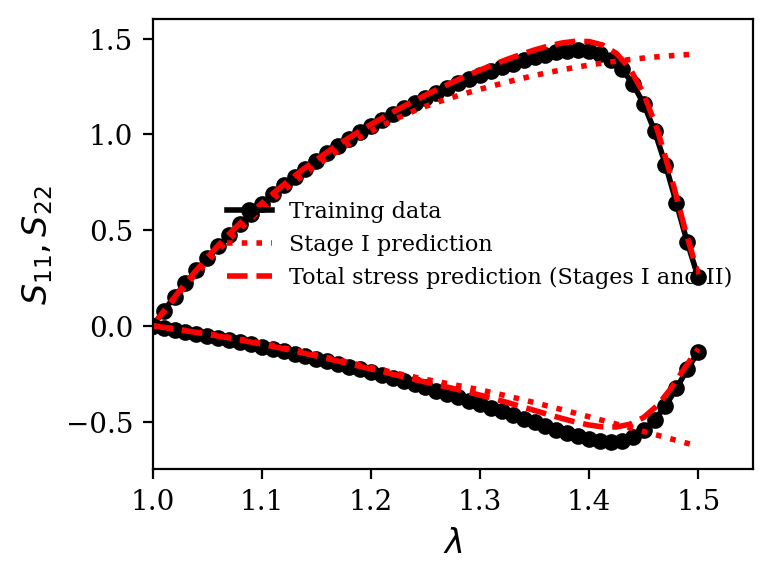

In [39]:
# Plot 4a: Model predictions of stage I vs total predicted stress.
plt.rc('font', family='serif')
plt.rcParams["figure.autolayout"] = True
plt.rc('xtick', labelsize='medium')
plt.rc('ytick', labelsize='medium')
plt.rc('axes', labelsize='large')

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

ax.plot(F11_train, S11_training, c = 'k', marker = 'o', markersize = '5', linewidth = 2, label = 'Training data') #marker = 'o', markersize = '5',
ax.plot(F11[40:], np.array(S11_h_test)[40:], color = 'r', linestyle = ':', linewidth = 2, label = 'Stage I prediction')
ax.plot(F11[40:], np.array(S11_test)[40:], c = 'r', linestyle = '--', linewidth = 2, label = 'Total stress prediction (Stages I and II)')

ax.plot(F11_train, S22_training, marker = 'o', markersize = '5', c = 'k', linewidth = 2)
ax.plot(F11[40:], np.array(S22_h_test)[40:], color = 'r', linestyle = ':', linewidth = 2)
ax.plot(F11[40:], np.array(S22_test)[40:], c = 'r', linestyle = '--', linewidth = 2)

plt.ylim((-0.75, 1.6))
plt.xlim((1, 1.55))

ax.set_xlabel('$\lambda$')
ax.set_ylabel('$S_{11}, S_{22}$')
ax.legend(frameon=False, prop={'size': 8})
plt.savefig("../results/Stage_I_vs_Stage_II_stresses.svg")
plt.show()

<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\c'
<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\c'
C:\Users\kshit\AppData\Local\Temp\ipykernel_53776\21565215.py:22: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda$')
C:\Users\kshit\AppData\Local\Temp\ipykernel_53776\21565215.py:23: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('$\chi$')
C:\Users\kshit\AppData\Local\Temp\ipykernel_53776\21565215.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, prop={'size': 8})


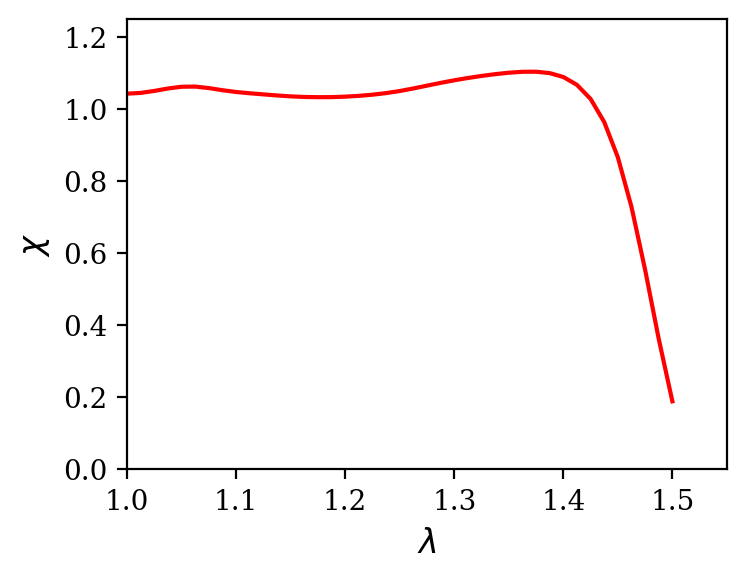

In [40]:
# Plot 4b: Predicted stress-reduction factor (input of Stage II) vs stretch.
plt.rc('font', family='serif')
plt.rcParams["figure.autolayout"] = True
plt.rc('xtick', labelsize='medium')
plt.rc('ytick', labelsize='medium')
plt.rc('axes', labelsize='large')

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

ax.plot(F11, output_test, c = 'r', linestyle = '-')

plt.ylim((0, 1.25))
plt.xlim((1, 1.55))
ax.set_xlabel('$\lambda$')
ax.set_ylabel('$\chi$')
ax.legend(frameon=False, prop={'size': 8})
plt.savefig("../results/Xi_vs_stretch.svg")
plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\l'
C:\Users\kshit\AppData\Local\Temp\ipykernel_53776\4145537688.py:19: SyntaxWarning: invalid escape sequence '\p'
  ax.plot(F11[40:], np.array(W_test)[40:], c = 'r', linestyle = '--', linewidth = 2, label = '$\psi$, Total strain energy density prediction (Stages I and II)')
C:\Users\kshit\AppData\Local\Temp\ipykernel_53776\4145537688.py:24: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda$')


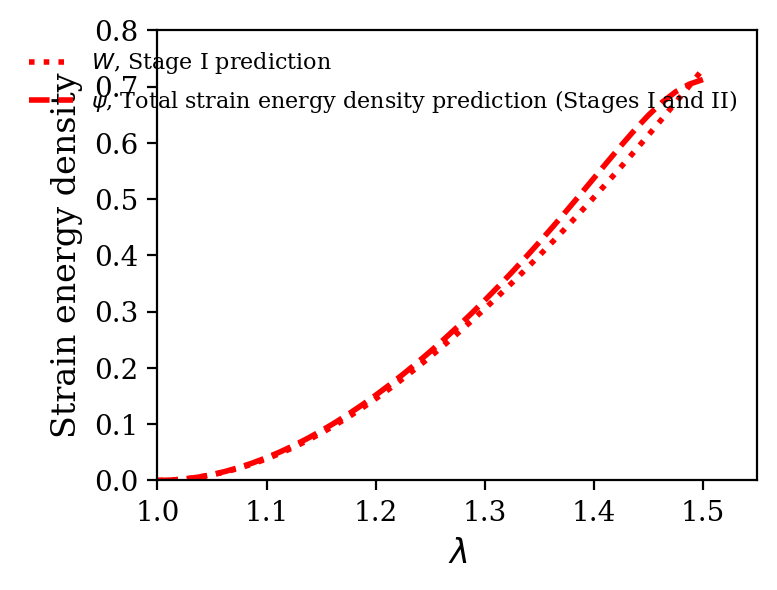

In [41]:
# Plot 4c: Strain energy density predictions of stage I vs stage II.
plt.rc('font', family='serif')
plt.rcParams["figure.autolayout"] = True
plt.rc('xtick', labelsize='medium')
plt.rc('ytick', labelsize='medium')
plt.rc('axes', labelsize='large')

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

ax.plot(F11[40:], np.array(W_h_test)[40:], color = 'r', linestyle = ':', linewidth = 2, label = '$W$, Stage I prediction')
ax.plot(F11[40:], np.array(W_test)[40:], c = 'r', linestyle = '--', linewidth = 2, label = '$\psi$, Total strain energy density prediction (Stages I and II)')

plt.ylim((0, 0.8))
plt.xlim((1, 1.55))

ax.set_xlabel('$\lambda$')
ax.set_ylabel('Strain energy density')
ax.legend(frameon=False, prop={'size': 8})
plt.savefig("../results/Stage_I_vs_Stage_II_energies.svg")
plt.show()

<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
C:\Users\kshit\AppData\Local\Temp\ipykernel_53776\1025628776.py:23: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda$')


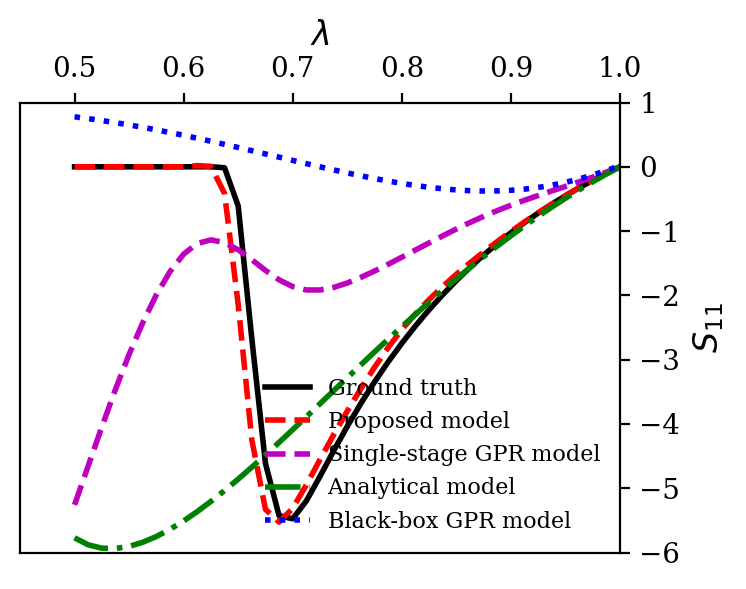

In [42]:
# Plot 5a: Model predictions in the compressive testing regime_S11.

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

ax.xaxis.tick_top()
ax.yaxis.tick_right()
ax.xaxis.set_label_position('top') 
ax.yaxis.set_label_position('right') 

ax.plot(F11, S11_ground_truth, c = 'k', linewidth = 2, label = 'Ground truth')
ax.plot(F11, S11_test, c = 'r', linestyle = '--', linewidth = 2, label = 'Proposed model')
ax.plot(F11, S11_test_GPR_direct, c = 'm', linestyle = '--', linewidth = 2, label = 'Single-stage GPR model')
ax.plot(F11, S11_YH, c = 'g', linestyle = '-.', linewidth = 2, label = 'Analytical model')
ax.plot(F11, S11_test_6_6, c = 'b', linestyle = ':', linewidth = 2, label = 'Black-box GPR model')
ax.set_xlabel('$\lambda$')
ax.set_ylabel('$S_{11}$')
plt.ylim((-6, 1))
plt.xlim((0.45,1))

ax.legend(frameon=False, prop={'size': 8})
plt.savefig("../results/Hyperelastic_testing_comp_prediction_11.svg")
plt.show()

<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
C:\Users\kshit\AppData\Local\Temp\ipykernel_53776\161772544.py:23: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda$')


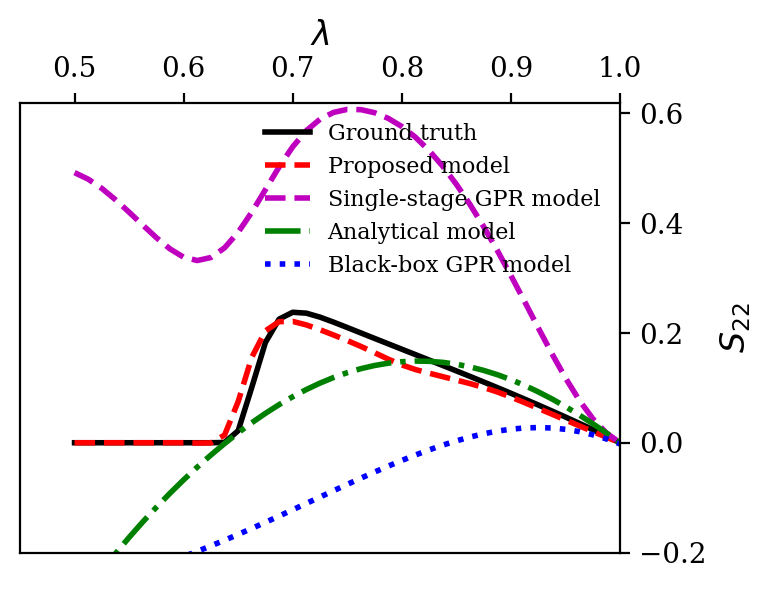

In [43]:
# Plot 5b: Model predictions in the compressive testing regime_S22.

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

ax.xaxis.tick_top()
ax.yaxis.tick_right()
ax.xaxis.set_label_position('top') 
ax.yaxis.set_label_position('right')

ax.plot(F11, S22_ground_truth, c = 'k', linewidth = 2, label = 'Ground truth')
ax.plot(F11, S22_test, c = 'r', linestyle = '--', linewidth = 2, label = 'Proposed model')
ax.plot(F11, S22_test_GPR_direct, c = 'm', linestyle = '--', linewidth = 2, label = 'Single-stage GPR model')
ax.plot(F11, S22_YH, c = 'g', linestyle = '-.', linewidth = 2, label = 'Analytical model')
ax.plot(F11, S22_test_6_6, c = 'b', linestyle = ':', linewidth = 2, label = 'Black-box GPR model')
ax.set_xlabel('$\lambda$')
ax.set_ylabel('$S_{22}$')
plt.ylim((-0.2, 0.62))
plt.xlim((0.45,1))

ax.legend(frameon=False, prop={'size': 8})
plt.savefig("../results/Hyperelastic_testing_comp_prediction_22.svg")
plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
C:\Users\kshit\AppData\Local\Temp\ipykernel_53776\3672706346.py:21: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda$')


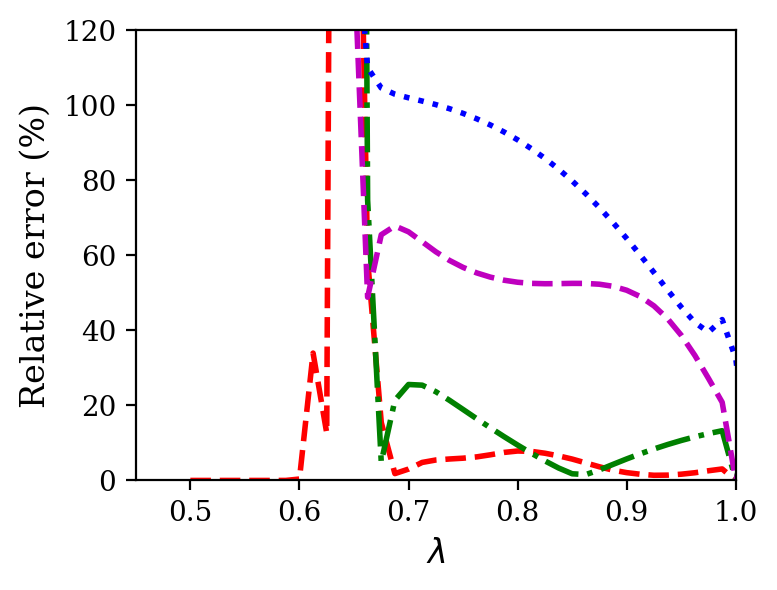

In [44]:
# Plot 5c: Relative error metric versus (lambda stretch) in the compressive testing regime.

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

plt.xlim([0.45, 1])
plt.ylim([0, 120])

ax.plot(F11, 100 * np.array(err_test_overall[:81]), c = 'r', linestyle = '--', linewidth = 2, label = 'Surrogate model')
ax.plot(F11, 100 * np.array(err_YH_overall[:81]), c = 'g', linestyle = '-.', linewidth = 2, label = 'Yeoh model')
ax.plot(F11, 100 * np.array(err_test_6_6_overall[:81]), c = 'b', linestyle = ':', linewidth = 2, label = 'Classical 6$-$6 mapping')
ax.plot(F11, 100 * np.array(err_test_GPR_direct_overall[:81]), c = 'm', linestyle = '--', linewidth = 2, label = 'Single-stage GPR model')

ax.set_xlabel('$\lambda$')
ax.set_ylabel('Relative error (%)')
plt.savefig("../results/Hyperelastic_testing_compression_fitting_error.svg")
plt.show()

<>:22: SyntaxWarning: invalid escape sequence '\g'
<>:22: SyntaxWarning: invalid escape sequence '\g'
C:\Users\kshit\AppData\Local\Temp\ipykernel_53776\2894076029.py:22: SyntaxWarning: invalid escape sequence '\g'
  ax.set_xlabel('$\gamma$')


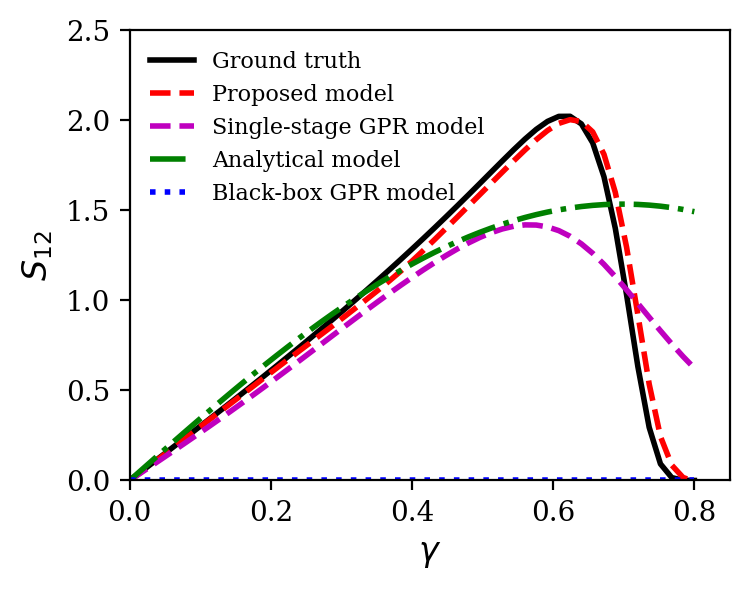

In [45]:
# Plot 6a: Model predictions in the shear testing regime_S12. 

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

plt.xlim([0, 0.85])
plt.ylim([0, 2.5])

ax.plot(F12, S12_ground_truth_sh, c = 'k', linewidth = 2, label = 'Ground truth')
ax.plot(F12, S12_test_sh, c = 'r', linestyle = '--', linewidth = 2, label = 'Proposed model')
ax.plot(F12, S12_test_GPR_direct_sh, c = 'm', linestyle = '--', linewidth = 2, label = 'Single-stage GPR model')
ax.plot(F12, S12_YH_sh, c = 'g', linestyle = '-.', linewidth = 2, label = 'Analytical model')
ax.plot(F12, S12_test_6_6_sh, c = 'b', linestyle = ':', linewidth = 2, label = 'Black-box GPR model')

ax.set_xlabel('$\gamma$')
ax.set_ylabel('$S_{12}$')
ax.legend(frameon=False, prop={'size': 8})
plt.savefig("../results/Hyperelastic_testing_shear_prediction_12.svg")
plt.show()

<>:54: SyntaxWarning: invalid escape sequence '\g'
<>:54: SyntaxWarning: invalid escape sequence '\g'
C:\Users\kshit\AppData\Local\Temp\ipykernel_53776\2225275082.py:54: SyntaxWarning: invalid escape sequence '\g'
  ax.set_xlabel('$\gamma$')


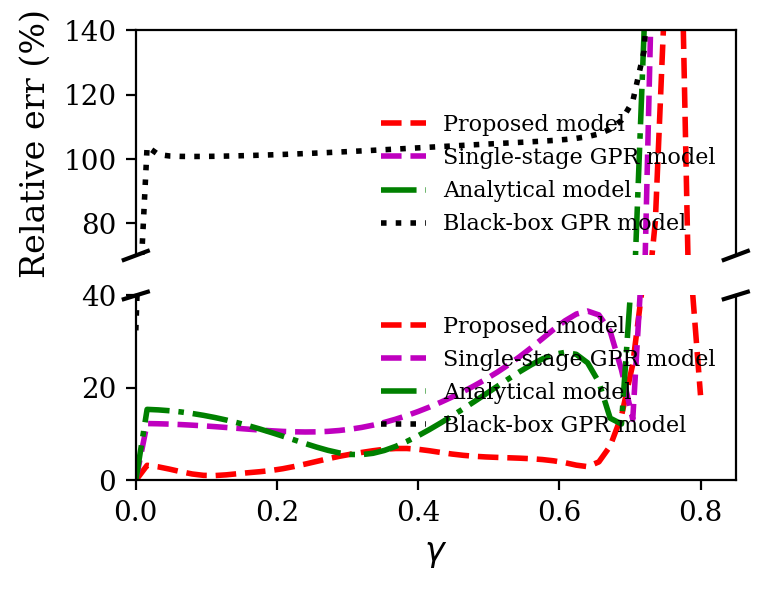

In [46]:
# Plot 6b: Model performance (errors) in the shear testing regime. 

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)] # Order: [left, width]
v = [Size.Fixed(0), Size.Fixed(2.25/2 - 0.2)] # Order: [bottom, height]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)

h2 = [Size.Fixed(0), Size.Fixed(3)] # Order: [left, width]
v2 = [Size.Fixed(2.25/2), Size.Fixed(2.25/2)] # Order: [bottom, height]
divider2 = Divider(fig, (0, 0, 1, 1), h2, v2, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1)) # ax is the bottom axis.
ax2 = fig.add_axes(divider2.get_position(),
                  axes_locator=divider2.new_locator(nx=1, ny=1)) # ax2 is the top axis.
fig.set_tight_layout(False)

ax2.set_ylim(70, 140)  # Top axis
ax.set_ylim(0, 40)  # Bottom axis

# The two x-axis limits defined below MUST be the idential.
ax2.set_xlim(0, 0.85)  # Top axis
ax.set_xlim(0, 0.85)  # Bottom axis

# Hide the spines between ax and ax2
ax2.spines['bottom'].set_visible(False)
ax.spines['top'].set_visible(False)
ax2.xaxis.tick_bottom()
ax2.tick_params(labelbottom=False)  # don't put tick labels at the bottom
ax2.tick_params(labeltop=False)  # don't put tick labels at the top
ax2.tick_params(bottom=False)  # don't put tick marks at the bottom
ax.tick_params(labeltop=False)  # don't put tick labels at the top

d = .02  # how big to make the diagonal lines in axes coordinates
# arguments to pass to plot, just so we don't keep repeating them
kwargs = dict(transform=ax2.transAxes, color='k', clip_on=False)
ax2.plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
ax2.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal

kwargs.update(transform=ax.transAxes)  # switch to the bottom axes
ax.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
ax.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal

ax.plot(F12, 100 * np.array(err_test_overall[81:]), c = 'r', linestyle = '--', linewidth = 2, label = 'Proposed model')
ax.plot(F12, 100 * np.array(err_test_GPR_direct_overall[81:]), c = 'm', linestyle = '--', linewidth = 2, label = 'Single-stage GPR model')
ax.plot(F12, 100 * np.array(err_YH_overall[81:]), c = 'g', linestyle = '-.', linewidth = 2, label = 'Analytical model')
ax.plot(F12, 100 * np.array(err_test_6_6_overall[81:]), c = 'k', linestyle = ':', linewidth = 2, label = 'Black-box GPR model')
ax2.plot(F12, 100 * np.array(err_test_overall[81:]), c = 'r', linestyle = '--', linewidth = 2, label = 'Proposed model')
ax2.plot(F12, 100 * np.array(err_test_GPR_direct_overall[81:]), c = 'm', linestyle = '--', linewidth = 2, label = 'Single-stage GPR model')
ax2.plot(F12, 100 * np.array(err_YH_overall[81:]), c = 'g', linestyle = '-.', linewidth = 2, label = 'Analytical model')
ax2.plot(F12, 100 * np.array(err_test_6_6_overall[81:]), c = 'k', linestyle = ':', linewidth = 2, label = 'Black-box GPR model')

ax.set_xlabel('$\gamma$')
ax2.set_ylabel('Relative err (%)')
ax.legend(frameon=False, prop={'size': 8})
ax2.legend(frameon=False, prop={'size': 8})

plt.savefig("../results/Hyperelastic_testing_shear_prediction_errors.svg")
plt.show()

<>:28: SyntaxWarning: invalid escape sequence '\c'
<>:28: SyntaxWarning: invalid escape sequence '\c'
C:\Users\kshit\AppData\Local\Temp\ipykernel_53776\293501931.py:28: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('$\chi$')


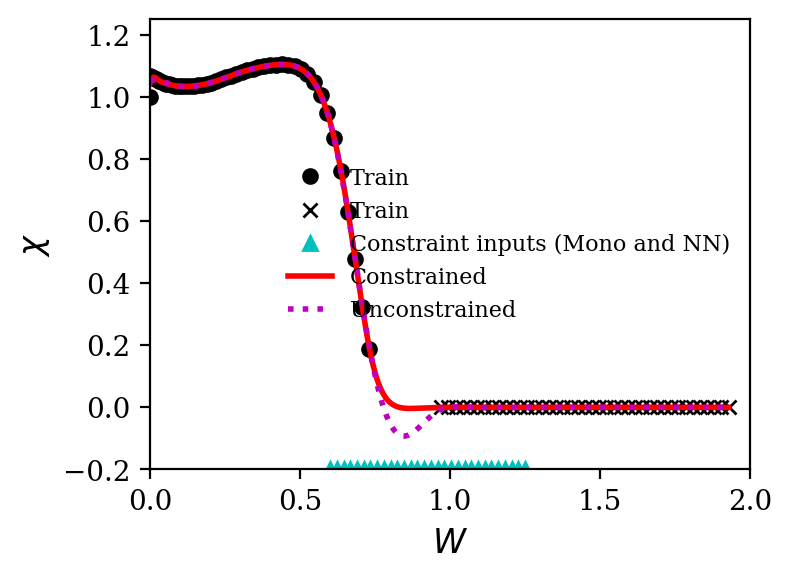

In [47]:
# Plot 7a: Predicted stress-reduction factor as a function of W (M_dam prediction): constrained vs unconstrained GPR.
plt.rc('font', family='serif')
plt.rcParams["figure.autolayout"] = True
plt.rc('xtick', labelsize='medium')
plt.rc('ytick', labelsize='medium')
plt.rc('axes', labelsize='large')

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

ax.plot(input_training_GPR3_ext[np.where(input_training_GPR3_ext<=0.8)], output_training_GPR3_ext[np.where(input_training_GPR3_ext<=0.8)], color='k',  markersize = '5', linewidth = 0, marker='o', label='Train')
ax.plot(input_training_GPR3_ext[np.where(input_training_GPR3_ext>0.8)], output_training_GPR3_ext[np.where(input_training_GPR3_ext>0.8)], color='k',  markersize = '5', linewidth = 0, marker='x', label='Train')
ax.plot(x_cons, np.zeros(np.shape(x_cons))-0.2, color='c', marker='^',  markersize = '5', linewidth = 0, label='Constraint inputs (Mono and NN)')
ax.plot(x_test, mu_pen, c = 'r', linewidth = 2, linestyle = '-', label="Constrained")
ax.plot(x_test, mu_std, c = 'm', linewidth = 2, linestyle = ':', label="Unconstrained")

plt.ylim((-0.2, 1.25))
plt.xlim((0, 2))

ax.set_xlabel('$W$')
ax.set_ylabel('$\chi$')
ax.legend(frameon=False, prop={'size': 8})
plt.savefig("../results/Constrained_VS_NotConstrained_Xi_vs_W.svg")
plt.show()

<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
C:\Users\kshit\AppData\Local\Temp\ipykernel_53776\4099056136.py:24: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda$')


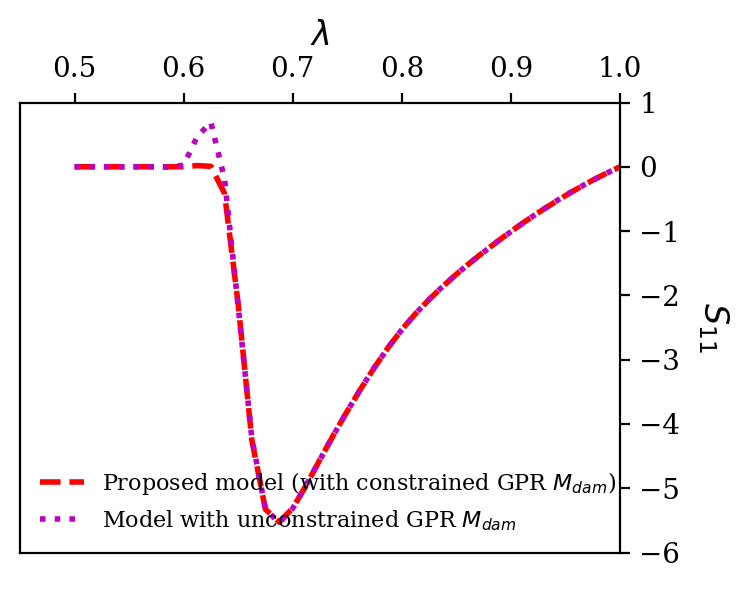

In [48]:
# Plot 7b: Comparing model predictions in the compressive testing regime_S11 with and without constrained GPR in Stage II.

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

ax.xaxis.tick_top()
ax.yaxis.tick_right()
ax.xaxis.set_label_position('top') 
ax.yaxis.set_label_position('right') 

ax.plot(F11, S11_test, c = 'r', linestyle = '--', linewidth = 2, label = 'Proposed model (with constrained GPR $M_{dam}$)')
ax.plot(F11, S11_test_stdGPR, c = 'm', linestyle = ':', linewidth = 2, label = 'Model with unconstrained GPR $M_{dam}$')

plt.ylim((-6, 1))
plt.xlim((0.45,1))

ax.set_xlabel('$\lambda$')
ax.set_ylabel('$S_{11}$', rotation = 270, labelpad=18)
ax.legend(frameon=False, prop={'size': 8})
plt.savefig("../results/Constrained_VS_NotConstrained_GPR_comp_11.svg")
plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\g'
<>:19: SyntaxWarning: invalid escape sequence '\g'
C:\Users\kshit\AppData\Local\Temp\ipykernel_53776\3683183355.py:19: SyntaxWarning: invalid escape sequence '\g'
  ax.set_xlabel('$\gamma$')


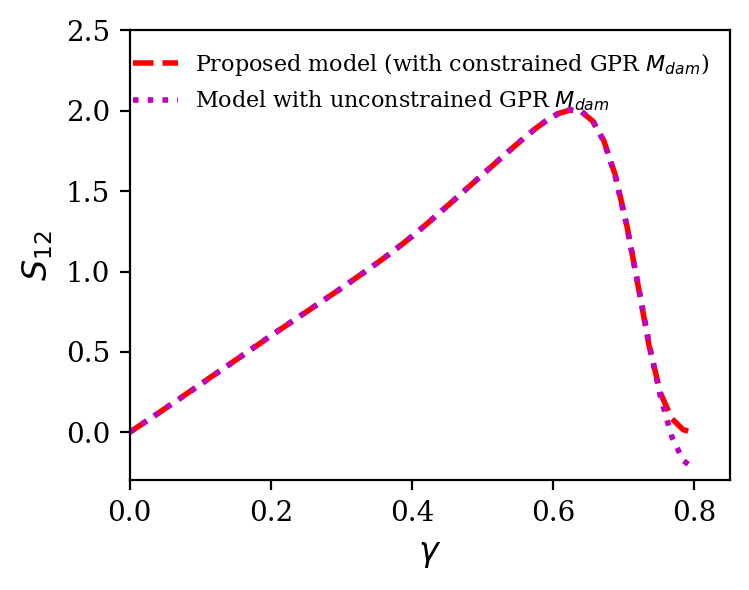

In [49]:
# Plot 7c: Comparing model predictions in the shear testing regime_S12 with and without constrained GPR in Stage II.

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

plt.xlim([0, 0.85])
plt.ylim([-0.3, 2.5])

ax.plot(F12, S12_test_sh, c = 'r', linestyle = '--', linewidth = 2, label = 'Proposed model (with constrained GPR $M_{dam}$)')
ax.plot(F12, S12_test_stdGPR_sh, c = 'm', linestyle = ':', linewidth = 2, label = 'Model with unconstrained GPR $M_{dam}$')

ax.set_xlabel('$\gamma$')
ax.set_ylabel('$S_{12}$')
ax.legend(frameon=False, prop={'size': 8})
plt.savefig("../results/Constrained_VS_NotConstrained_GPR_shear_12.svg")
plt.show()